In [1]:
import sys
import os
import json
import joblib
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# --- CONFIGURATION ---
CURRENT_DIR = os.getcwd()
ROOT_DIR = os.path.dirname(CURRENT_DIR) # streaming_emulator
DATA_DIR = os.path.join(ROOT_DIR, "data", "vehicles", "sim001")

# Pointing exactly to the local artifacts folder inside static_inference
ARTIFACTS_DIR = os.path.join(CURRENT_DIR, "artifacts")
OUTPUT_DIR = os.path.join(CURRENT_DIR, "output")

# Simulation Settings
SIM_ID = "sim001"
SCENARIO = "scenarioA"
MODULES = ["engine", "body", "battery", "transmission", "tyre"]
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"🚀 Device: {DEVICE}")
print(f"📂 Data Source: {DATA_DIR}")
print(f"📂 Local Artifacts: {ARTIFACTS_DIR}")

🚀 Device: cpu
📂 Data Source: C:\streaming_emulator\data\vehicles\sim001
📂 Local Artifacts: C:\streaming_emulator\static_inference\artifacts


In [2]:

class LSTMAutoencoder(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=2, dropout=0.2):
        super(LSTMAutoencoder, self).__init__()
        self.encoder = nn.LSTM(
            input_size=input_dim, hidden_size=hidden_dim, 
            num_layers=num_layers, batch_first=True, 
            dropout=dropout if num_layers > 1 else 0
        )
        self.decoder = nn.LSTM(
            input_size=hidden_dim, hidden_size=input_dim, 
            num_layers=num_layers, batch_first=True, 
            dropout=dropout if num_layers > 1 else 0
        )

    def forward(self, x):
        encoded, (hidden, cell) = self.encoder(x)
        repeated_hidden = hidden[-1].unsqueeze(1).repeat(1, x.size(1), 1)
        decoded, _ = self.decoder(repeated_hidden)
        return decoded

In [5]:
def validate_vehicle_schema(modules, sim_id):
    print(f"\n🛡️ PRE-FLIGHT CHECK FOR {sim_id.upper()}...")
    global_status = True
    module_reports = {}

    for mod in modules:
        filename = f"synthetic_{mod}_inference_{SCENARIO}_{sim_id}.csv"
        csv_path = os.path.join(DATA_DIR, filename)
        meta_path = os.path.join(ARTIFACTS_DIR, mod, "model_meta.json")
        feats_path = os.path.join(ARTIFACTS_DIR, mod, "features.json")
        
        if not os.path.exists(csv_path) or not os.path.exists(meta_path) or not os.path.exists(feats_path):
            print(f"   ❌ {mod.upper()}: Files Missing (Ensure artifacts are copied to {ARTIFACTS_DIR}\\{mod})")
            global_status = False
            continue
            
        try:
            with open(feats_path) as f: expected_features = json.load(f)["features"]
            
            df_cols = pd.read_csv(csv_path, nrows=0).columns.tolist()
            available_raw = set(df_cols)
            
            missing_features = [feat for feat in expected_features if feat not in available_raw]
            raw_missing_count = len(missing_features)
            
            if raw_missing_count > 3:
                print(f"   ⛔ {mod.upper()}: CRITICAL. Missing {raw_missing_count} Contract Sensors.")
                print("      Missing Sensors:")
                for col in sorted(missing_features):
                    print(f"        - {col}")
                global_status = False
                
            elif raw_missing_count > 0:
                print(f"   ⚠️  {mod.upper()}: WARNING. Missing {raw_missing_count} Contract Sensors.")
                for col in sorted(missing_features):
                    print(f"        - {col}")
                print("      (Masking features & imputing baseline values to protect Health Score.)")
                module_reports[mod] = missing_features 
            else:
                print(f"   ✅ {mod.upper()}: OK")
                module_reports[mod] = []
                
        except Exception as e:
            print(f"   ❌ {mod.upper()}: Error - {e}")
            global_status = False

    return global_status, module_reports

In [6]:
def run_masked_inference(module_name, missing_features):
    print(f"   ⚙️  Inferencing: {module_name}...")
    
    filename = f"synthetic_{module_name}_inference_{SCENARIO}_{SIM_ID}.csv"
    df = pd.read_csv(os.path.join(DATA_DIR, filename))
    timestamps = pd.to_datetime(df['timestamp']) if 'timestamp' in df.columns else pd.to_datetime(df['date'])
    
    path = os.path.join(ARTIFACTS_DIR, module_name)
    with open(os.path.join(path, "model_meta.json")) as f: meta = json.load(f)
    with open(os.path.join(path, "features.json")) as f: expected_cols = json.load(f)["features"]
    
    scaler = joblib.load(os.path.join(path, "scaler.pkl"))
    gmm = joblib.load(os.path.join(path, "gmm.pkl")) # Using GMM
    
    lstm = LSTMAutoencoder(input_dim=len(expected_cols)).to(DEVICE)
    lstm.load_state_dict(torch.load(os.path.join(path, "lstm_model.pt"), map_location=DEVICE, weights_only=True))
    lstm.eval()
    
    # --- Data Prep & Imputation ---
    df_numeric = df.select_dtypes(include=[np.number]).copy()
    df_final = df_numeric.reindex(columns=expected_cols)
    df_final = df_final.ffill() # Forward fill gaps
    for col in expected_cols:
        if col in meta.get('feature_means', {}):
            df_final[col] = df_final[col].fillna(meta['feature_means'][col])
        else:
            df_final[col] = df_final[col].fillna(0.0)
    
    mask_indices = [expected_cols.index(c) for c in missing_features]
    
    try:
        X_scaled = scaler.transform(df_final)
    except Exception as e:
        print(f"      ❌ Scaler failed: {e}")
        return None
        
    window_size = meta["sequence_length"]
    sequences = [X_scaled[i : i + window_size] for i in range(len(X_scaled) - window_size + 1)]
    if not sequences: return None
    
    X_tensor = torch.tensor(np.array(sequences), dtype=torch.float32).to(DEVICE)
    results = []
    
    lstm_thresh = meta["lstm_thresholds"]
    gmm_thresh = meta["gmm_thresholds"]
    
    # --- SMART INFERENCE STATE VARIABLES ---
    ema_error = 0.0          
    ALPHA = 0.2              # EMA Smoothing factor
    persistence_counter = 0  
    PERSISTENCE_LIMIT = 5    # Ticks required for Critical Alert
    
    with torch.no_grad():
        for i in range(0, len(X_tensor), 512):
            batch = X_tensor[i : i+512]
            rec = lstm(batch)
            
            diff = (batch - rec)**2
            if mask_indices:
                mask = torch.ones_like(diff)
                mask[:, :, mask_indices] = 0.0
                diff = diff * mask
            
            rec_error = torch.mean(diff, dim=(1,2)).cpu().numpy()
            feat_diff = diff[:, -1, :].cpu().numpy()
            
            last_step_data = batch[:, -1, :].cpu().numpy()
            gmm_log_probs = gmm.score_samples(last_step_data)
            
            for j in range(len(batch)):
                raw_err = float(rec_error[j])
                
                # 1. EMA Smoothing
                if i == 0 and j == 0:
                    ema_error = raw_err
                else:
                    ema_error = (ALPHA * raw_err) + ((1 - ALPHA) * ema_error)
                
                # 2. GMM Familiarity Calculation
                log_prob = float(gmm_log_probs[j])
                limit = gmm_thresh['p05']
                
                if log_prob >= limit:
                    familiarity = 1.0 
                else:
                    scale = abs(limit - gmm_thresh['min']) + 1e-6
                    dist = abs(limit - log_prob)
                    familiarity = max(1.0 - (dist / scale), 0.0)

                # 3. Base Risk Calculation (Using Smoothed Error)
                if ema_error <= lstm_thresh["p95"]:
                    base_risk = 0.5 * (ema_error / max(lstm_thresh["p95"], 1e-6))
                elif ema_error <= lstm_thresh["p99_5"]:
                    base_risk = 0.5 + 0.3 * ((ema_error - lstm_thresh["p95"]) / max((lstm_thresh["p99_5"] - lstm_thresh["p95"]), 1e-6))
                else:
                    base_risk = 0.8 + 0.2 * min((ema_error - lstm_thresh["p99_5"]) / max((lstm_thresh["max"] - lstm_thresh["p99_5"]), 1e-6), 1.0)
                
                # 4. Regime-Based Logic (GMM Correction)
                final_comp = base_risk
                if familiarity > 0.8:
                    if base_risk < 0.9: 
                        final_comp = base_risk * 0.6 
                elif familiarity < 0.2:
                    final_comp = min(base_risk + 0.2, 1.0)
                
                # 5. Persistence Filter
                sev = "NORMAL"
                code = 0
                
                if final_comp >= 0.8:
                    persistence_counter += 1
                elif final_comp >= 0.5:
                    persistence_counter = max(0, persistence_counter - 1)
                    sev = "WARNING"
                    code = 1
                else:
                    persistence_counter = 0 
                
                if persistence_counter >= PERSISTENCE_LIMIT:
                    sev = "CRITICAL"
                    code = 2
                    final_comp = max(final_comp, 0.85)
                elif base_risk >= 0.8: 
                    sev = "WARNING"
                    code = 1

                row_feats = feat_diff[j]
                top_k = {expected_cols[k]: float(row_feats[k]) for k in np.argsort(row_feats)[-3:][::-1]}
                
                results.append({
                    "timestamp": timestamps.iloc[i+j+window_size-1],
                    "module": module_name,
                    "lstm_raw_error": raw_err,
                    "lstm_smoothed": ema_error,
                    "composite_score": final_comp,
                    "gmm_familiarity": familiarity,
                    "health_score": (1.0 - final_comp) * 100,
                    "severity": sev,
                    "top_features": json.dumps(top_k)
                })
                
    return pd.DataFrame(results)

In [7]:
is_go, report = validate_vehicle_schema(MODULES, SIM_ID)
final_results = {}

if is_go:
    print(f"\n🚀 RUNNING INFERENCE...")
    for mod in MODULES:
        df_res = run_masked_inference(mod, report[mod])
        if df_res is not None and not df_res.empty:
            # Save to output directory
            df_res.to_csv(os.path.join(OUTPUT_DIR, f"{mod}_inference.csv"), index=False)
            
            # Save to current directory directly (local)
            local_filename = f"{mod}_inference_final.csv"
            #df_res.to_csv(os.path.join(CURRENT_DIR, local_filename), index=False)
            
            final_results[mod] = df_res
            print(f"      ✅ {mod}: {len(df_res)} rows.")
            print(f"         -> Saved to {OUTPUT_DIR}")
            print(f"         -> Saved to Current Dir as {local_filename}")
else:
    print("\n❌ ABORTED due to schema violations. Fix missing columns in CSV files before inferencing.")


🛡️ PRE-FLIGHT CHECK FOR SIM001...
   ✅ ENGINE: OK
   ✅ BODY: OK
   ✅ BATTERY: OK
   ✅ TRANSMISSION: OK
   ✅ TYRE: OK

🚀 RUNNING INFERENCE...
   ⚙️  Inferencing: engine...


C:\streaming_emulator\.venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\streaming_emulator\.venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator GaussianMixture from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


      ✅ engine: 755971 rows.
         -> Saved to C:\streaming_emulator\static_inference\output
         -> Saved to Current Dir as engine_inference_final.csv
   ⚙️  Inferencing: body...


C:\streaming_emulator\.venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\streaming_emulator\.venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator GaussianMixture from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


      ✅ body: 755971 rows.
         -> Saved to C:\streaming_emulator\static_inference\output
         -> Saved to Current Dir as body_inference_final.csv
   ⚙️  Inferencing: battery...


...

      ✅ battery: 755971 rows.
         -> Saved to C:\streaming_emulator\static_inference\output
         -> Saved to Current Dir as battery_inference_final.csv
   ⚙️  Inferencing: transmission...


C:\streaming_emulator\.venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\streaming_emulator\.venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator GaussianMixture from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


      ✅ transmission: 755971 rows.
         -> Saved to C:\streaming_emulator\static_inference\output
         -> Saved to Current Dir as transmission_inference_final.csv
   ⚙️  Inferencing: tyre...


C:\streaming_emulator\.venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\streaming_emulator\.venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator GaussianMixture from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


      ✅ tyre: 641768 rows.
         -> Saved to C:\streaming_emulator\static_inference\output
         -> Saved to Current Dir as tyre_inference_final.csv


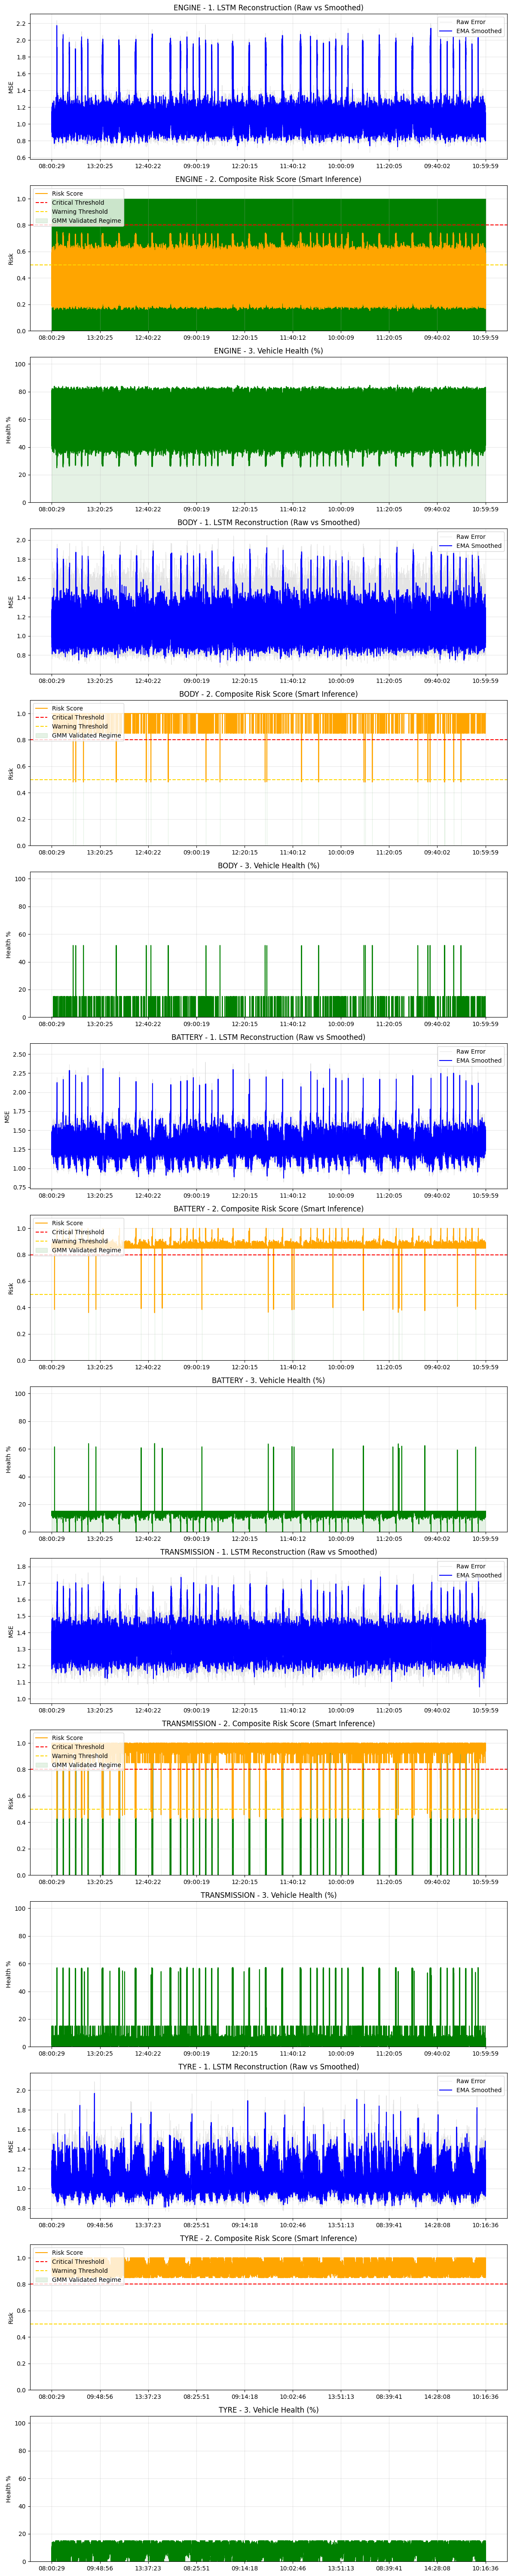

In [8]:

if not final_results:
    print("⚠️ No data to plot. Inference was aborted or failed to produce results.")
else:
    fig, axes = plt.subplots(len(final_results) * 3, 1, figsize=(12, 4 * len(final_results) * 3), sharex=False)
    if not isinstance(axes, np.ndarray): axes = [axes]
    
    idx = 0
    for mod, df in final_results.items():
        # Sequential Index to skip physical time gaps
        x_axis = range(len(df))
        
        # Format timestamps for ticks
        n_ticks = 10
        if len(df) > n_ticks:
            tick_indices = np.linspace(0, len(df)-1, n_ticks, dtype=int)
            tick_labels = [pd.to_datetime(df['timestamp'].iloc[i]).strftime('%H:%M:%S') for i in tick_indices]
        else:
            tick_indices = range(len(df))
            tick_labels = [pd.to_datetime(df['timestamp'].iloc[i]).strftime('%H:%M:%S') for i in tick_indices]

        # --- 1. LSTM Raw vs Smoothed ---
        ax1 = axes[idx]
        ax1.plot(x_axis, df['lstm_raw_error'], color='lightgray', alpha=0.6, linewidth=0.8, label='Raw Error')
        ax1.plot(x_axis, df['lstm_smoothed'], color='blue', linewidth=1.5, label='EMA Smoothed')
        ax1.set_title(f"{mod.upper()} - 1. LSTM Reconstruction (Raw vs Smoothed)")
        ax1.grid(True, alpha=0.3)
        ax1.set_ylabel("MSE")
        ax1.legend(loc='upper right')
        
        # --- 2. Composite Score (Risk) ---
        ax2 = axes[idx+1]
        ax2.plot(x_axis, df['composite_score'], color='orange', linewidth=1.5, label='Risk Score')
        ax2.axhline(0.8, color='red', linestyle='--', label='Critical Threshold')
        ax2.axhline(0.5, color='gold', linestyle='--', label='Warning Threshold')
        
        if 'gmm_familiarity' in df.columns:
            high_familiarity = df['gmm_familiarity'] > 0.8
            # Align fill_between boolean masking with x_axis index
            ax2.fill_between(x_axis, 0, 1, where=high_familiarity.values, color='green', alpha=0.1, label='GMM Validated Regime')

        ax2.set_title(f"{mod.upper()} - 2. Composite Risk Score (Smart Inference)")
        ax2.set_ylabel("Risk")
        ax2.set_ylim(0, 1.1)
        ax2.legend(loc='upper left')
        ax2.grid(True, alpha=0.3)
        
        # --- 3. Health Score ---
        ax3 = axes[idx+2]
        ax3.plot(x_axis, df['health_score'], color='green', linewidth=1.5)
        ax3.set_title(f"{mod.upper()} - 3. Vehicle Health (%)")
        ax3.set_ylabel("Health %")
        ax3.set_ylim(0, 105)
        ax3.fill_between(x_axis, df['health_score'], 0, color='green', alpha=0.1)
        ax3.grid(True, alpha=0.3)
        
        for ax in [ax1, ax2, ax3]:
            ax.set_xticks(tick_indices)
            ax.set_xticklabels(tick_labels)
        
        idx += 3

    plt.tight_layout()
    plt.show()

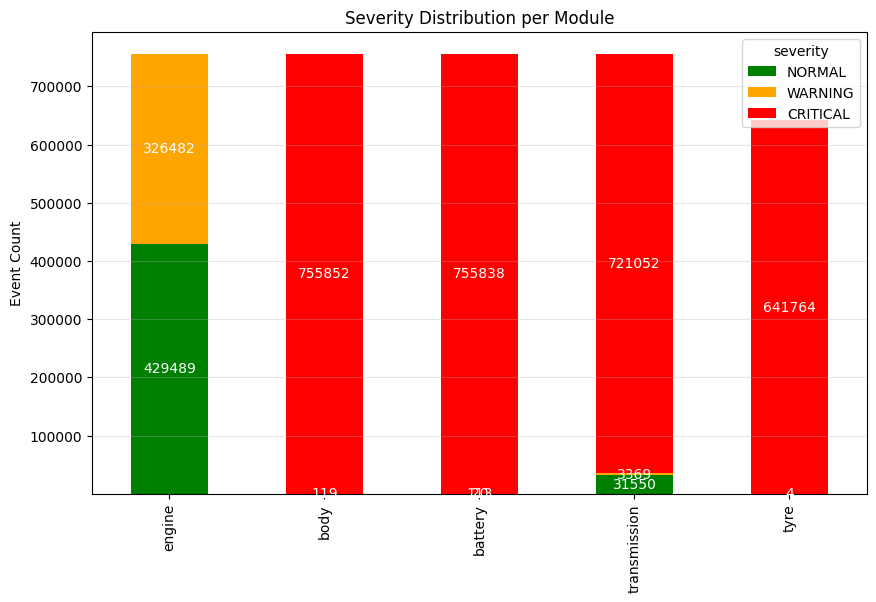

In [9]:
if not final_results:
    print("⚠️ No data to plot. Inference was aborted or failed to produce results.")
else:
    severity_counts = {}

    for mod, df in final_results.items():
        counts = df['severity'].value_counts()
        severity_counts[mod] = counts

    sev_df = pd.DataFrame(severity_counts).fillna(0).T
    for col in ['NORMAL', 'WARNING', 'CRITICAL']:
        if col not in sev_df.columns: sev_df[col] = 0
    
    sev_df = sev_df[['NORMAL', 'WARNING', 'CRITICAL']]

    ax = sev_df.plot(kind='bar', stacked=True, figsize=(10, 6), color=['green', 'orange', 'red'])
    plt.title("Severity Distribution per Module")
    plt.ylabel("Event Count")
    plt.grid(axis='y', alpha=0.3)
    
    for c in ax.containers:
        ax.bar_label(c, label_type='center', color='white')
        
    plt.show()